## Experiment 01

## 1. Experiment Settings
- Sample size (n): 5000
- X1 dimension (d): 10
- X2 dimension (p): 500
- X1 and X2 are independent.
- Linear relationship between predictor (X1 only) and response (Y).
- Data were generated randomly 5 times to get 5 results from each model for analyzation.

In [1]:
import sys
sys.path.append("../src")

from generate_predictors import generate_predictors
from sklearn.model_selection import train_test_split

from models.lasso import tune_lasso
from models.lasso import fit_lasso

from models.ridge import tune_ridge
from models.ridge import fit_ridge

from models.random_forest import tune_random_forest
from models.random_forest import fit_random_forest

from models.neural_network import tune_neural_network
from models.neural_network import fit_neural_network

import numpy as np

## 2. Simulation

### Data Generation 1

In [2]:
np.random.seed(32)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Lasso Replicate 1

In [3]:
lasso_result = []

In [4]:
print(tune_lasso(X_train, Y_train, alphas = [0.1, 0.5, 1.0]))

{'best_alpha': 0.1, 'best_cv_mse': 1.0208613757271912, 'tuning_runtime': 0.9712257001083344}


In [5]:
l1 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.1)
lasso_result.append(l1)

### Ridge Replicate 1

In [6]:
ridge_result = []
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 10, 'best_cv_mse': 1.1497314444657252, 'tuning_runtime': 1.091270700097084}


In [7]:
r1 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=10)
ridge_result.append(r1)

### Random Forest Replicate 1

In [8]:
rf_result = []
print(tune_random_forest(
    X_train, Y_train, param_grid = {'n_estimators': [100], 'max_depth': [3, 7], "min_samples_leaf": [1, 5]}))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'best_params': {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 2.180193709711431, 'tuning_runtime': 251.88020459981635}


In [9]:
rf1 = fit_random_forest(
    X_train, Y_train, X_test, Y_test, params = {'n_estimators': 100, 'max_depth': 7, "min_samples_leaf": 5})
rf_result.append(rf1)

### Neural Network Replicate 1

In [10]:
nn_result = []
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\selin\anaconda3\envs\py310\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'best_params': {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 4.335914487312263, 'tuning_runtime': 9.47303540003486}


In [11]:
nn1 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.0001, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn1)

### Data generation 2

In [12]:
np.random.seed(23)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Lasso Replicate 2

In [13]:
print(tune_lasso(X_train, Y_train, alphas = [0.1, 0.5, 1.0]))

{'best_alpha': 0.1, 'best_cv_mse': 1.056324876262133, 'tuning_runtime': 0.713677000021562}


In [14]:
l2 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.1)
lasso_result.append(l2)

### Ridge Replicate 2

In [15]:
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 10, 'best_cv_mse': 1.2414047206513246, 'tuning_runtime': 1.5992774001788348}


In [16]:
r2 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=10)
ridge_result.append(r2)

### Random Forest Replicate 2

In [17]:
print(tune_random_forest(X_train, Y_train, param_grid = {
    'n_estimators': [100], 'max_depth': [3, 5, 7], "min_samples_leaf": [1, 5]}))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'best_params': {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 2.193218532835348, 'tuning_runtime': 295.4580308001023}


In [18]:
rf2 = fit_random_forest(X_train, Y_train, X_test, Y_test, params = {
    'n_estimators': 100, 'max_depth': 7, "min_samples_leaf": 5})
rf_result.append(rf2)

### Neural Network Replicate 2

In [19]:
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'best_params': {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 4.409318612600106, 'tuning_runtime': 6.871583000058308}


In [20]:
nn2 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.0001, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn2)

### Data Generation 3

In [21]:
np.random.seed(56)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Lasso Replicate 3

In [22]:
print(tune_lasso(X_train, Y_train, alphas = [0.1, 0.5, 1.0]))

{'best_alpha': 0.1, 'best_cv_mse': 1.0346554296925206, 'tuning_runtime': 0.7350856000557542}


In [23]:
l3 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.1)
lasso_result.append(l3)

### Ridge Replicate 3

In [24]:
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 10, 'best_cv_mse': 1.180200185574825, 'tuning_runtime': 0.8925136998295784}


In [25]:
r3 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=10)
ridge_result.append(r3)

### Random Forest Replicate 3

In [26]:
print(tune_random_forest(X_train, Y_train, param_grid = {'n_estimators': [100], 'max_depth': [3, 5, 7], "min_samples_leaf": [1, 5]}))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'best_params': {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 2.2074486166258493, 'tuning_runtime': 2345.8607479999773}


In [27]:
rf3 = fit_random_forest(X_train, Y_train, X_test, Y_test, params = {'n_estimators': 100, 'max_depth': 7, "min_samples_leaf": 5})
rf_result.append(rf3)

### Neural Network Replicate 3

In [28]:
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\selin\anaconda3\envs\py310\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'best_params': {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 4.409920495882077, 'tuning_runtime': 9.940242700045928}


In [29]:
nn3 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.0001, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn3)

### Data Generation 4

In [30]:
np.random.seed(44)

# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Lasso Replicate 4

In [31]:
print(tune_lasso(X_train, Y_train, alphas = [0.1, 0.5, 1.0]))

{'best_alpha': 0.1, 'best_cv_mse': 1.0551398972197616, 'tuning_runtime': 0.6513060999568552}


In [32]:
l4 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.1)
lasso_result.append(l4)

### Ridge Replicate 4

In [33]:
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 10, 'best_cv_mse': 1.1987736557610067, 'tuning_runtime': 0.8778955000452697}


In [34]:
r4 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=10)
ridge_result.append(r4)

### Random Forest Replicate 4

In [35]:
print(tune_random_forest(X_train, Y_train, param_grid = {'n_estimators': [100], 'max_depth': [3, 5, 7], "min_samples_leaf": [1, 5]}))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'best_params': {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 2.3028927965973005, 'tuning_runtime': 292.7035958999768}


In [36]:
rf4 = fit_random_forest(X_train, Y_train, X_test, Y_test, params = {'n_estimators': 100, 'max_depth': 7, "min_samples_leaf": 5})
rf_result.append(rf4)

### Neural Network Replicate 4

In [37]:
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'best_params': {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 4.46653257256091, 'tuning_runtime': 6.504337999969721}


In [38]:
nn4 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.0001, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn4)

### Data Generation 5

In [39]:
np.random.seed(90)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
Y = (
    3.0 * X1[:,0]
    -2.0 * X1[:,1]
    +1.5 * X1[:,2]
    -0.8 * X1[:,3]
    +noise
    )
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Lasso Replicate 5

In [40]:
print(tune_lasso(X_train, Y_train, alphas = [0.1, 0.5, 1.0]))

{'best_alpha': 0.1, 'best_cv_mse': 1.0309786644558592, 'tuning_runtime': 0.7545421000104398}


In [41]:
l5 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.1)
lasso_result.append(l5)

### Ridge Replicate 5

In [42]:
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 10, 'best_cv_mse': 1.1359333810122543, 'tuning_runtime': 0.9020507999230176}


In [43]:
r5 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=10)
ridge_result.append(r5)

### Random Forest Replicate 5

In [44]:
print(tune_random_forest(X_train, Y_train, param_grid = {'n_estimators': [100], 'max_depth': [3, 5, 7], "min_samples_leaf": [1, 5]}))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'best_params': {'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 2.2121188086438894, 'tuning_runtime': 315.5000003997702}


In [45]:
rf5 = fit_random_forest(X_train, Y_train, X_test, Y_test, params = {'n_estimators': 100, 'max_depth': 7, "min_samples_leaf": 5})
rf_result.append(rf5)

### Neural Network Replicate 5

In [46]:
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'best_params': {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 4.511186918796854, 'tuning_runtime': 5.954690400045365}


In [47]:
nn5 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.0001, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn5)

## 3. Evaluation

In [48]:
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_mse(
    lasso_results,
    ridge_results,
    rf_results,
    nn_results
):
    results = {
        "Lasso": lasso_results,
        "Ridge": ridge_results,
        "Random Forest": rf_results,
        "Neural Network": nn_results
    }

    data = []

    for model_name, model_results in results.items():
        for repeat, result in enumerate(model_results, start=1):
            data.append({
                "model": model_name,
                "repeat": repeat,
                "mse": result["mse"]
            })

    df = pd.DataFrame(data)

    return df

In [49]:
mse_df = evaluate_mse(
    lasso_result,
    ridge_result,
    rf_result,
    nn_result
)

print(mse_df)

             model  repeat       mse
0            Lasso       1  0.996039
1            Lasso       2  1.056202
2            Lasso       3  1.081797
3            Lasso       4  1.035355
4            Lasso       5  1.085791
5            Ridge       1  1.101454
6            Ridge       2  1.123339
7            Ridge       3  1.209982
8            Ridge       4  1.170568
9            Ridge       5  1.219631
10   Random Forest       1  2.127989
11   Random Forest       2  2.340959
12   Random Forest       3  2.137096
13   Random Forest       4  2.333603
14   Random Forest       5  2.133344
15  Neural Network       1  3.160219
16  Neural Network       2  3.231300
17  Neural Network       3  3.163197
18  Neural Network       4  3.274328
19  Neural Network       5  3.177089


In [50]:
average_mse = (
    mse_df
    .groupby("model")["mse"]
    .mean()
    .sort_values()
)

print(average_mse)

model
Lasso             1.051037
Ridge             1.164995
Random Forest     2.214598
Neural Network    3.201227
Name: mse, dtype: float64


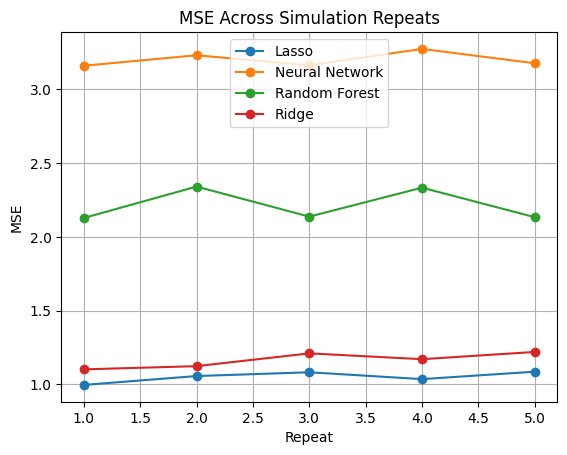

In [51]:
for model_name, group in mse_df.groupby("model"):
    plt.plot(
        group["repeat"],
        group["mse"],
        marker="o",
        label=model_name
    )

plt.xlabel("Repeat")
plt.ylabel("MSE")
plt.title("MSE Across Simulation Repeats")
plt.legend()
plt.grid(True)
plt.show()

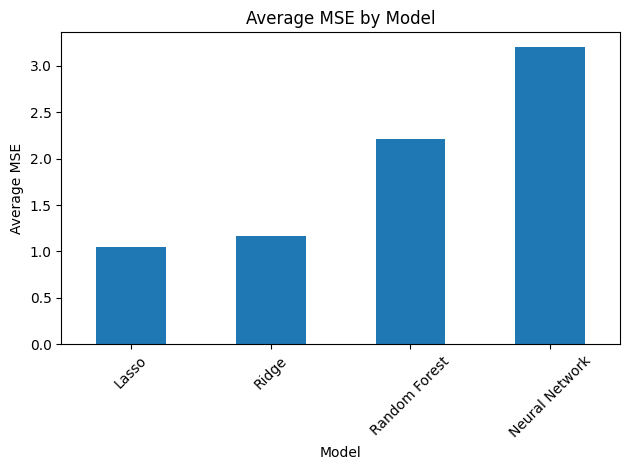

In [52]:
average_mse.plot(kind="bar")

plt.xlabel("Model")
plt.ylabel("Average MSE")
plt.title("Average MSE by Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion 
Lasso achieved the lowest MSE, followed by Ridge, while Random Forest and the Neural Network performed worse. This suggests that Lasso is well suited for sparse linear relationships, where only a small number of predictors contribute to the response.